In [154]:
import json
import os

path = os.getcwd().split('/')[:-1]
filename = '/'.join(path) + '/dataset/real-action-state-dataset.json'

with open(filename, 'r') as f:
    real_data = json.load(f)

path = os.getcwd().split('/')[:-1]
filename = '/'.join(path) + '/dataset/sim-action-state-dataset.json'

with open(filename, 'r') as f:
    sim_data = json.load(f)


In [155]:
types = set()
for rollout in real_data['data']:
    types.add(rollout['type'])

print(types)


{'square', 'prbs', 'triangle', 'step', 'ramp', 'chirp'}


In [156]:
def compute_loss(rollout_type, data1, data2):
    for rollout1 in data1['data']:
        if rollout1['type'] == rollout_type:
            break

    for rollout2 in data2['data']:
        if rollout2['type'] == rollout_type:
            break

    sim_states = np.array(rollout1['sensor_data'])
    real_states = np.array(rollout2['sensor_data'])
    
    loss = np.mean(np.square(sim_states - real_states[:, 0]))

    print(loss)

    return sim_states, real_states



In [157]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rollout(rollout_type, data):
    for rollout in data['data']:
        if rollout['type'] == rollout_type:
            break

    # actions = np.array(rollout['actions'])
    states = np.array(rollout['sensor_data'])

    # plt.plot(actions)
    plt.plot(states)


0.00010574005546686374


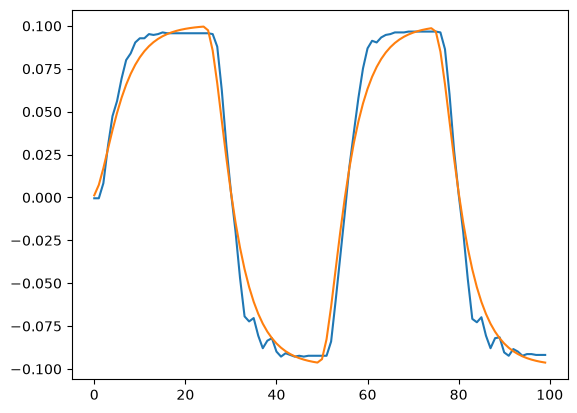

0.000537670852760415


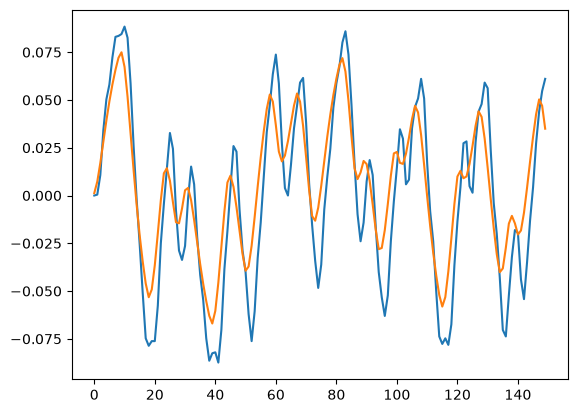

0.0001285144030467456


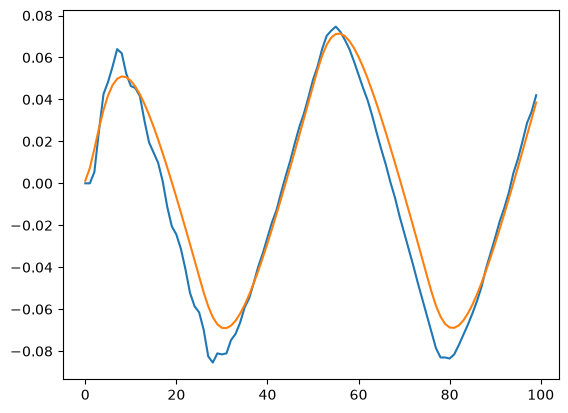

0.005126301409779865


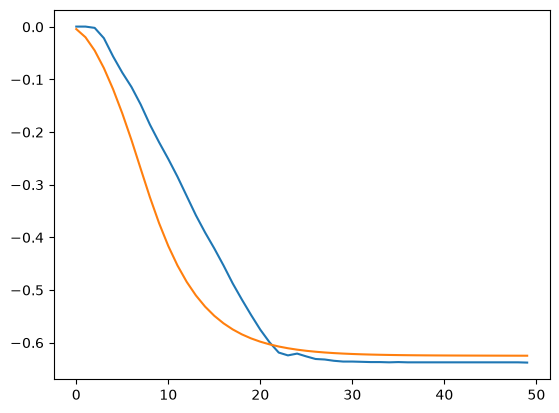

0.0004262409552886365


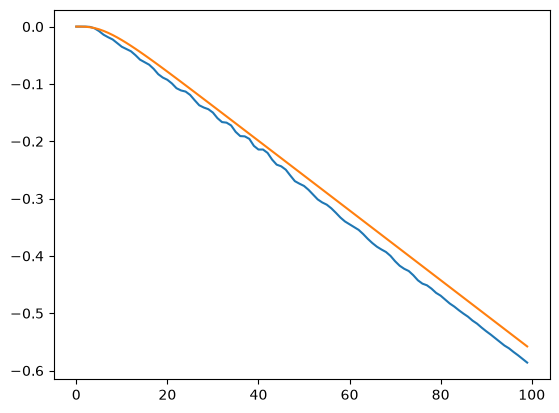

0.004049601663432638


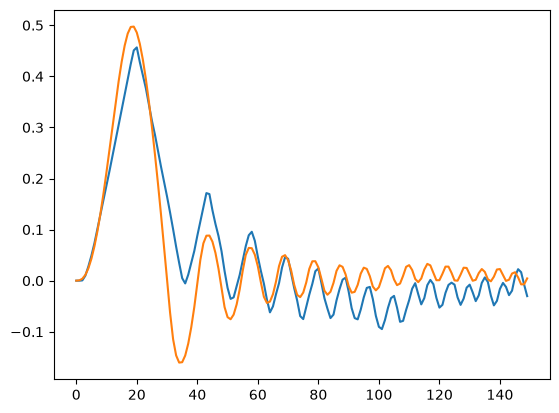

In [158]:
for key in ['square', 'prbs', 'triangle', 'step', 'ramp', 'chirp']:
    sim, real = compute_loss(key, real_data, sim_data)
    plt.plot(sim)
    plt.plot(real)
    plt.show()


# learned Tau

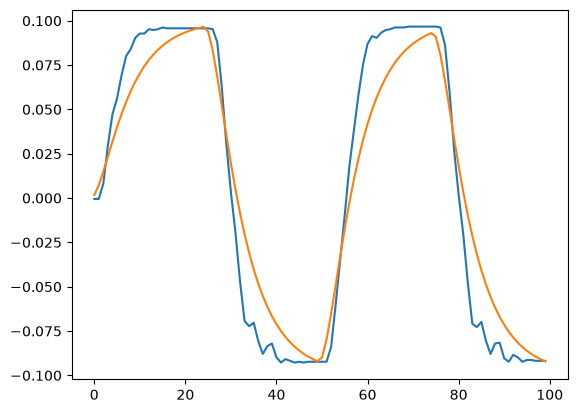

0.011159771182481166


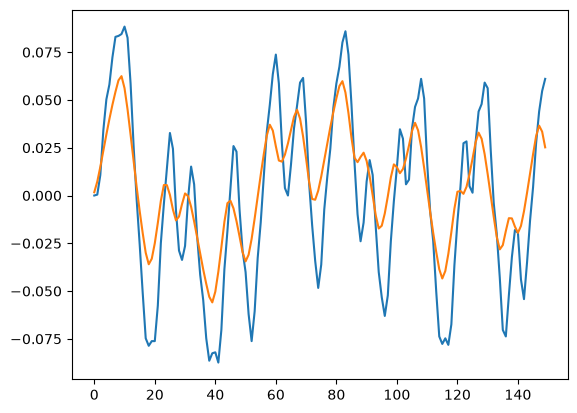

0.002928479891501093


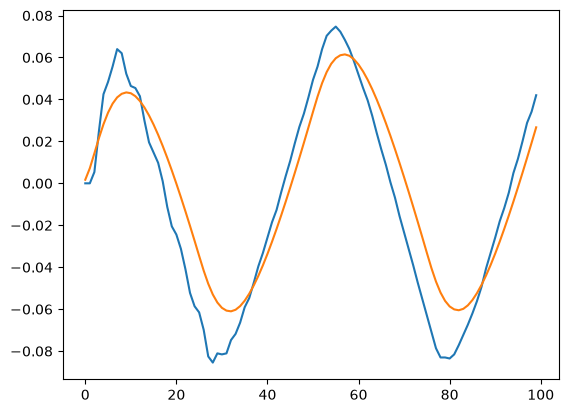

0.003953688494137552


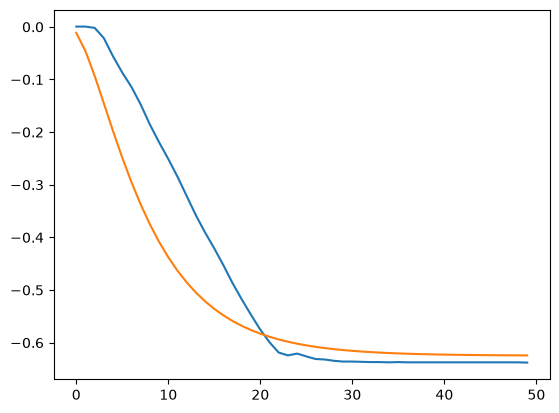

0.07894792875201548


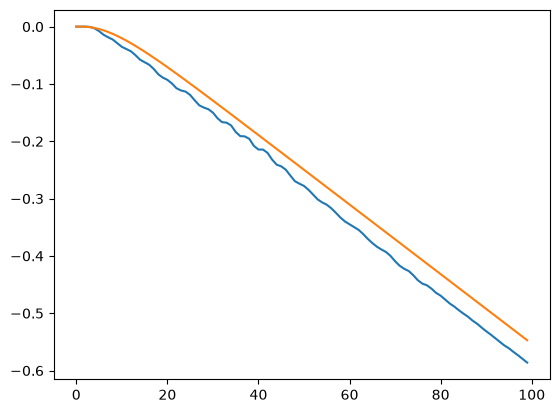

0.061516962743404624


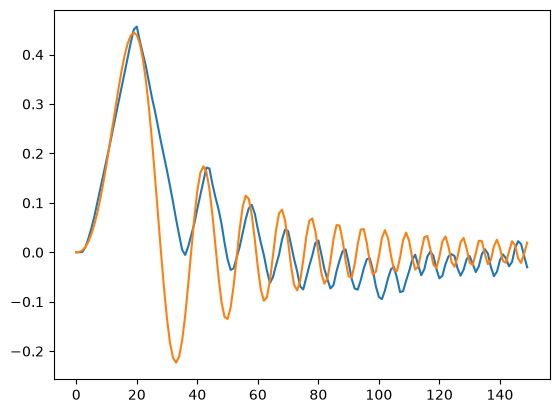

0.032578629976000785


In [76]:
for key in ['square', 'prbs', 'triangle', 'step', 'ramp', 'chirp']:
    sim, real = compute_loss(key, real_data, sim_data)
    plt.plot(sim)
    plt.plot(real)
    plt.show()


# Original guessed values

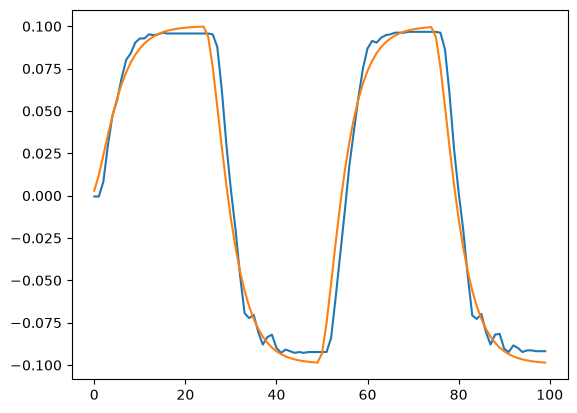

0.012916355954171474


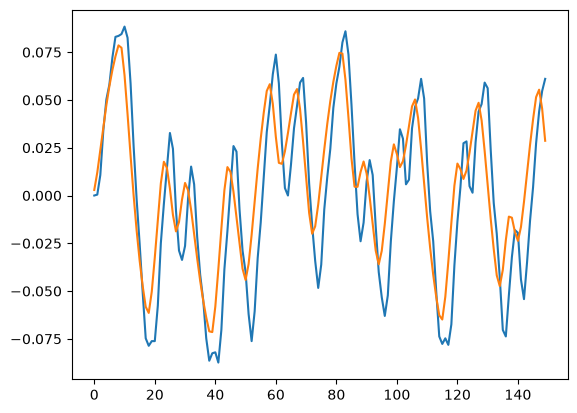

0.003522370841548391


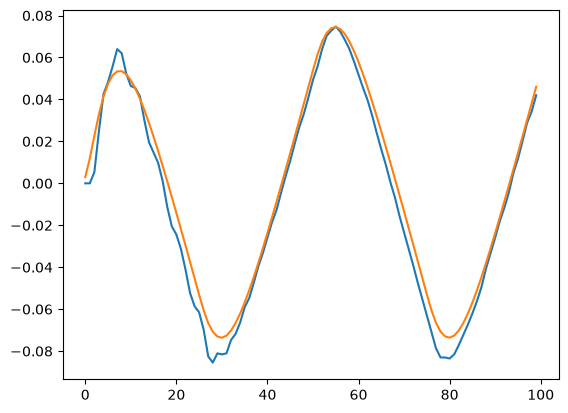

0.0045762328488400976


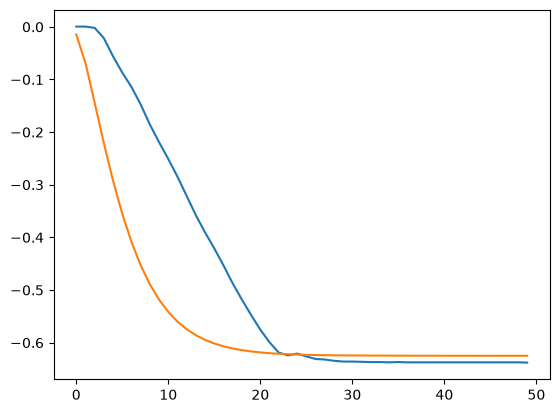

0.07752089045560451


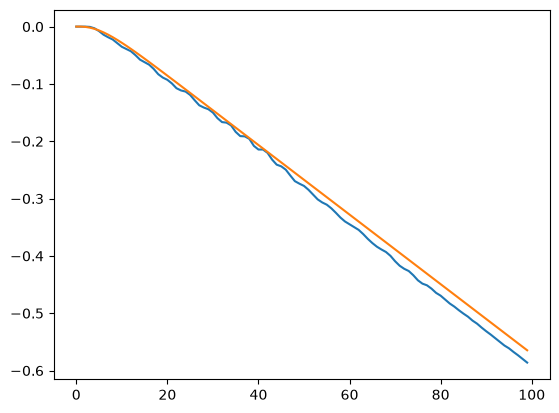

0.061967156448885


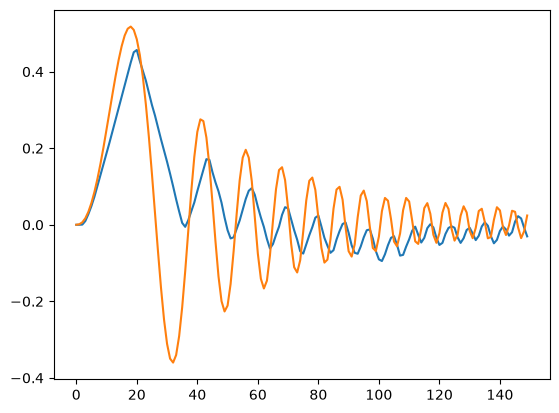

0.043918055856941224


In [91]:
for key in ['square', 'prbs', 'triangle', 'step', 'ramp', 'chirp']:
    plot_rollout(key, real_data)
    plot_rollout(key, sim_data)
    plt.show()
    compute_loss(key, real_data, sim_data)